In [2]:
cd("/home/ritaferi/Phd/SSDdev/")
using Pkg
Pkg.activate(".")
Pkg.instantiate()

using SolidStateDetectors
using Unitful
using Plots
using LegendHDF5IO
using HDF5



  Activating project at `~/Phd/SSDdev`


In [3]:
using Random
using SpecialFunctions
using Distributions

------

# Biorn implementation

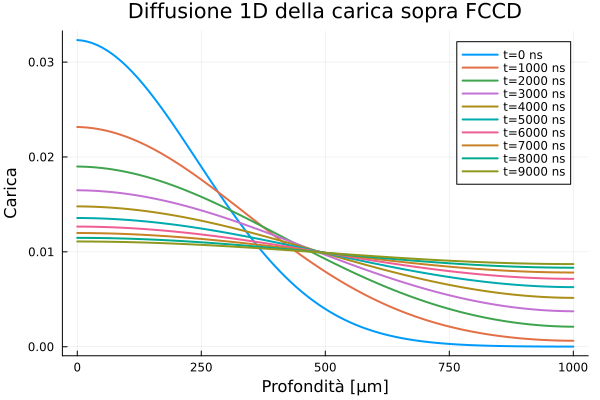

In [ ]:

D = 28.9; Δx = 10.0; Δt = 1.0
FCCD = 1000.0; x_c = 50.0; t_max = 10000

Nx = Int(FCCD/Δx)+1
Nt = Int(t_max/Δt)+1
f = D*Δt/Δx^2

C = zeros(Float64, Nx)
C_new = zeros(Float64, Nx)
idx_c = Int(round(x_c/Δx)) + 1
C[idx_c] = 1.0
x = 0:Δx:FCCD

# array per salvare curve da plottare
curves = Float64[]

time_steps_to_plot = 0:1000:10000

# --------------------------
# Loop temporale
# --------------------------
plots_to_show = []
for i in 1:Nt
    for j in 1:Nx
        left  = j == 1   ? C[j] : C[j-1]
        right = j == Nx  ? C[j] : C[j+1]
        C_new[j] = f*(left + right) + (1 - 2*f)*C[j]
    end
    C, C_new = C_new, C

    if i*Δt in time_steps_to_plot
        push!(plots_to_show, copy(C))
    end
end

# Plot finale
plot(x, plots_to_show[1], label="t=0 ns", lw=2)
for k in 2:length(plots_to_show)
    plot!(x, plots_to_show[k], label="t=$(time_steps_to_plot[k]) ns", lw=2)
end
xlabel!("Profondità [µm]")
ylabel!("Probabilità densità di Carica")
title!("Diffusione 1D della carica sopra FCCD")

In [10]:
using Plots

function diffusion_animation()

    # --------------------------
    # Parametri fisici
    # --------------------------
    D = 28.9
    Δx = 10.0
    Δt = 1.0
    FCCD = 1000.0
    x_c = 50.0
    t_max = 100

    # --------------------------
    # Discretizzazione
    # --------------------------
    Nx = Int(FCCD/Δx) + 1
    Nt = Int(t_max/Δt) + 1
    f = D * Δt / Δx^2

    println("f = $f (deve essere < 0.5 per stabilità)")

    # --------------------------
    # Inizializzazione
    # --------------------------
    C = zeros(Float64, Nx)
    C_new = zeros(Float64, Nx)

    idx_c = Int(round(x_c/Δx)) + 1
    C[idx_c] = 1.0

    x = 0:Δx:FCCD

    # --------------------------
    # Animazione
    # --------------------------
    anim = @animate for i in 1:1:Nt

        for j in 1:Nx
            left  = j == 1  ? C[j] : C[j-1]
            right = j == Nx ? C[j] : C[j+1]

            C_new[j] = f*(left + right) + (1 - 2f)*C[j]
        end

        C, C_new = C_new, C

        plot(x, C,
            ylim=(0,1),
            xlabel="Profondità [µm]",
            ylabel="Carica",
            title="Diffusione 1D   t=$(i*Δt) ns",
            lw=2)
    end

    #gif(anim, "diffusione_1D.gif", fps=30)

end

#diffusion_animation()

diffusion_animation (generic function with 1 method)

In [15]:
using Plots

function diffusion_density()

    # parametri fisici
    D = 28.9
    Δx = 10.0
    Δt = 1.0
    FCCD = 1000.0
    x_c = 50.0
    t_max = 100

    # numero di cariche generate
    Ntot = 100000.0

    Nx = Int(FCCD/Δx) + 1
    Nt = Int(t_max/Δt) + 1

    f = D * Δt / Δx^2

    println("f = $f")

    # numero di cariche nei bin
    N = zeros(Float64, Nx)
    N_new = zeros(Float64, Nx)

    idx_c = Int(round(x_c/Δx)) + 1
    N[idx_c] = Ntot

    x = 0:Δx:FCCD

    anim = @animate for i in 1:Nt

        for j in 1:Nx
            left  = j == 1  ? N[j] : N[j-1]
            right = j == Nx ? N[j] : N[j+1]

            N_new[j] = f*(left + right) + (1 - 2f)*N[j]
        end

        N, N_new = N_new, N

        # densità di carica
        ρ = N ./ Δx

        plot(x, ρ,
            xlabel="Profondità (µm)",
            ylabel="densità di carica ρ (cariche/µm)",
            title="Diffusione cariche t=$(i*Δt) ns",
            lw=2)
    end

    gif(anim,"diffusion_density.gif",fps=20)

end

#diffusion_density()

diffusion_density (generic function with 1 method)

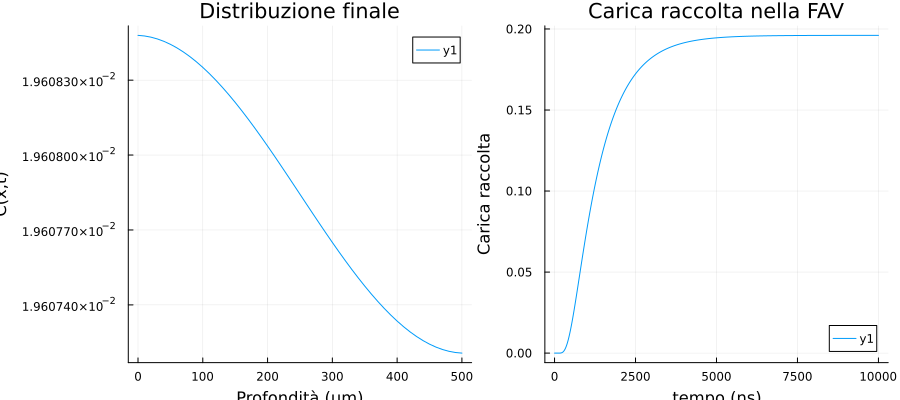

In [11]:


function diffusion_collection()

    # parametri
    D = 28.9
    Δx = 10.0
    Δt = 1.0
    FCCD = 500.0
    x_c = 50.0
    t_max = 10000

    Nx = Int(FCCD/Δx)+1
    Nt = Int(t_max/Δt)+1

    f = D*Δt/Δx^2

    C = zeros(Float64,Nx)
    C_new = zeros(Float64,Nx)

    idx_c = Int(round(x_c/Δx))+1
    C[idx_c] = 1.0

    x = 0:Δx:FCCD

    collected = zeros(Nt)
    Q = 0.0

    for i in 1:Nt

        # diffusione
        for j in 1:Nx
            left  = j==1  ? C[j] : C[j-1]
            right = j==Nx ? C[j] : C[j+1]

            C_new[j] = f*(left+right) + (1-2f)*C[j]
        end

        C, C_new = C_new, C

        # flusso alla FCCD
        dCdx = (C[Nx] - C[Nx-1]) / Δx
        J = -D * dCdx

        # carica raccolta
        Q += J * Δt

        collected[i] = Q
    end

    t = (1:Nt) .* Δt

    p1 = plot(x,C,
        xlabel="Profondità (µm)",
        ylabel="C(x,t)",
        title="Distribuzione finale")

    p2 = plot(t,collected,
        xlabel="tempo (ns)",
        ylabel="Carica raccolta",
        title="Carica raccolta nella FAV")

    plot(p1,p2,layout=(1,2),size=(900,400))

end

diffusion_collection()

----

## singola carica

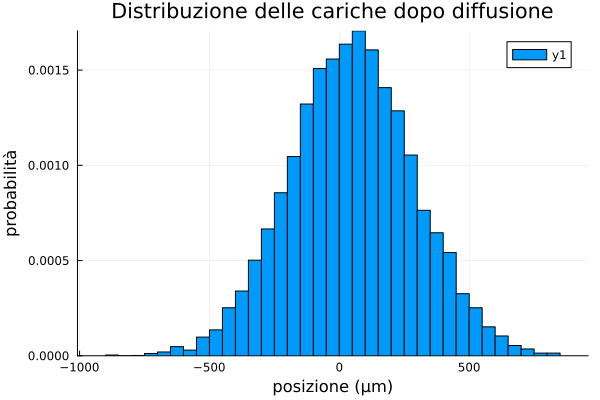

In [12]:
using Random
using Plots

function many_particles()

    D = 28.9
    Δt = 1.0
    t_max = 1000

    Nparticles = 10000
    Nt = Int(t_max/Δt)

    σ = sqrt(2*D*Δt)

    x = fill(50.0, Nparticles)

    for i in 1:Nt
        x .+= σ .* randn(Nparticles)
    end

    histogram(x,
        bins=50,
        normalize=true,
        xlabel="posizione (µm)",
        ylabel="probabilità",
        title="Distribuzione delle cariche dopo diffusione")

end

many_particles()

In [1]:


function single_charge_random_walk()

    # parametri fisici
    D = 28.9          # micron^2/ns
    Δt = 1.0          # ns
    t_max = 10000

    Nt = Int(t_max/Δt)

    # posizione iniziale
    x = zeros(Nt)
    x[1] = 0

    σ = sqrt(2*D*Δt)

    for i in 2:Nt
        step = σ * randn()
        x[i] = x[i-1] + step
    end

    t = (1:Nt) .* Δt

    plot(t, x,
        xlabel="tempo (ns)",
        ylabel="posizione (µm)",
        title="Random walk di una singola carica",
        lw=2)

end

single_charge_random_walk()

UndefVarError: UndefVarError: `plot` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

-----------

## detector

name: TrueCoaxial
units:
  length: mm
  angle: deg
  potential: V
  temperature: K
grid:
  coordinates: cylindrical
  axes:
    r:
      to: 10.01
      boundaries: inf
    phi:
      from: 0
      to: 0
      boundaries:
        left: periodic
        right: periodic
    z:
      from: -0.01
      to: 10.01
      boundaries:
        left: inf
        right: inf
medium: vacuum
detectors:
- semiconductor:
    material: HPGe
    temperature: 90
    impurity_density:
      name: PtypePNjunction
      lithium_annealing_temperature: 623K
      lithium_annealing_time: 18minute
      doped_contact_id: 2
      bulk_impurity_density:
        name: constant
        value: -1e10cm^-3
    charge_drift_model:
      model: InactiveLayerChargeDriftModel
      temperature: 90K
      neutral_impurity_density:
        name: constant
        value: 5.6769e15cm^-3
      # # Uncomment the following lines if you want to use different bulk and surface impurity densities in the charge_drift_model section
    

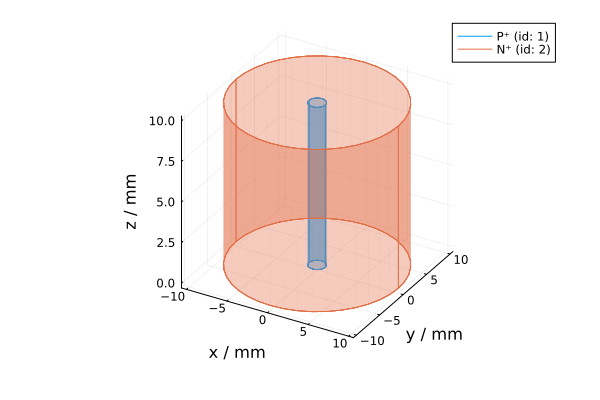

In [11]:
det_rin = 1u"mm"
det_z = det_r = 10u"mm"
z_draw = det_z/2
pn_r = 8.957282u"mm" # this one was calculated by searching the zero impurity point (displayed in the following section)

T = Float64;
sim = Simulation{T}(SSD_examples[:TrueCoaxial])
cfn = SSD_examples[:TrueCoaxial]
print(open(f -> read(f, String), cfn))
plot(sim.detector, xunit = u"mm", yunit = u"mm", zunit = u"mm")

--------------

In [ ]:
#1D
function random_walk_1d(N; l=1.0)
    steps = rand([-l, l], N)        # genera N passi ±l
    x = cumsum(steps)               # posizione nel tempo
    return x
end

# Parametri
N = 100
x = random_walk_1d(N)

plot(x,
     xlabel="Passo",
     ylabel="Posizione",
     title="Random Walk 1D",
     legend=false)

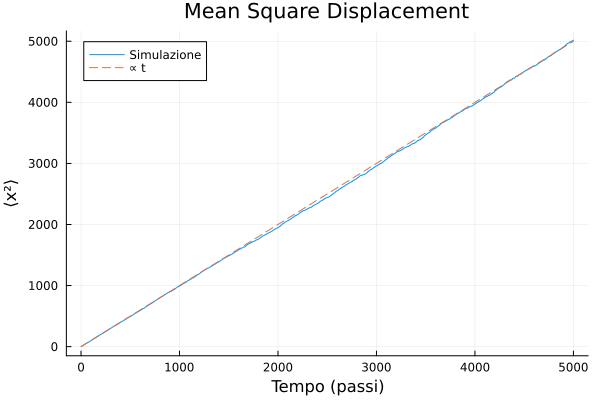

In [10]:
#2D
using Statistics

function ensemble_mean_square(N, M; l=1.0)
    msd = zeros(N)

    for m in 1:M
        x = random_walk_1d(N, l=l)
        msd .+= x.^2
    end

    return msd ./ M
end

N = 5000       # passi
M = 10000       # numero di traiettorie

msd = ensemble_mean_square(N, M)

plot(1:N, msd,
     xlabel="Tempo (passi)",
     ylabel="⟨x²⟩",
     title="Mean Square Displacement",
     label="Simulazione")

plot!(1:N, (1:N), linestyle=:dash, label="∝ t")